In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/asteroids.csv')
print('shape:', df.shape, '\n')
print('data types:')
print(df.dtypes, '\n')
print('null elements:')
print(df.isnull().sum())
df.head()

shape: (338199, 9) 

data types:
neo_id                      int64
name                          str
absolute_magnitude        float64
estimated_diameter_min    float64
estimated_diameter_max    float64
orbiting_body                 str
relative_velocity         float64
miss_distance             float64
is_hazardous                 bool
dtype: object 

null elements:
neo_id                     0
name                       0
absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
orbiting_body              0
relative_velocity          0
miss_distance              0
is_hazardous               0
dtype: int64


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


In [62]:
df.describe()

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


In [63]:
df['orbiting_body'].unique()
# All objects in this dataset orbit Earth

<ArrowStringArray>
['Earth']
Length: 1, dtype: str

In [72]:
# 1. How many asteroids in the dataset are hazardous vs. non-hazardous?
print(df.groupby('is_hazardous')['name'].describe()['count'], '\n')
print('There are 295037 non-hazardous objects and 43162 hazardous objects orbiting Earth.')

is_hazardous
False    295037
True      43162
Name: count, dtype: object 

There are 295037 non-hazardous objects and 43162 hazardous objects orbiting Earth.


In [75]:
# 2. Are hazardous asteroids generally larger than non-hazardous ones?
df.groupby('is_hazardous')['estimated_diameter_min'].describe()

,count,mean,std,min,25%,50%,75%,max
is_hazardous,,,,,,,,
False,295009.0,0.138021,0.311454,0.000511,0.021805,0.055790,0.152952,37.545248
True,43162.0,0.293083,0.296549,0.082519,0.142087,0.199781,0.316632,4.023046


In [ ]:
df.groupby('is_hazardous')['estimated_diameter_max'].describe()
# The means in these tables imply hazardous asteroids are typically larger than non-hazardous
# This is apparent thanks to the large sample size

,count,mean,std,min,25%,50%,75%,max
is_hazardous,,,,,,,,
False,295009.0,0.308624,0.696433,0.001143,0.048757,0.124750,0.342011,83.953727
True,43162.0,0.655353,0.663103,0.184519,0.317717,0.446725,0.708011,8.995804


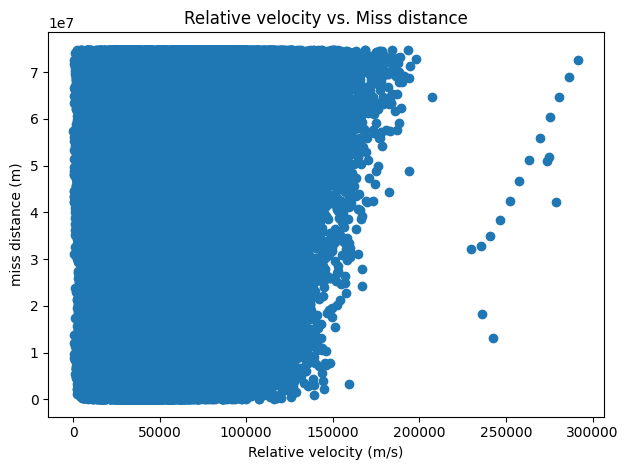

In [ ]:
# 3. Is there a relationship between velocity and miss distance?
plt.scatter(df['relative_velocity'], df['miss_distance'])
plt.title('Relative velocity vs. Miss distance')
plt.xlabel('Relative velocity (km/h)')
plt.ylabel('miss distance (km)')
plt.tight_layout()
plt.show()
# No apparent relationship between velocity and miss distance
# Curved path on the right side worth noting
# Maybe there is a relationship depending on grouping?
# TODO: observe the streak on the right side of the graph

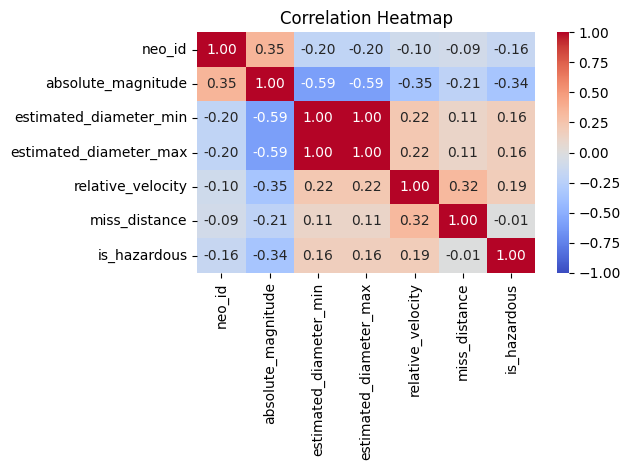

In [ ]:
# 4. What features correlate most strongly with an asteroid being hazardous?
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,
            cmap='coolwarm',
            annot=True,
            fmt='.2f',
            vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
# Absolute magnitude correlates most strongly with an asteroid being hazardous, with a correlation coefficient of -0.34
# After that is relative velocity, with a coefficient of 0.19
# Then diameter, with a coefficient of 0.16

In [ ]:
# 5. 